<a href="https://colab.research.google.com/github/scativa/IV-Colab/blob/Train_BA_x11/10_31_25_entrenamiento_segmentation_pretrained__lrvariable__wlc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Entorno

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from time import process_time_ns
import os, json

usr_drive = "evi.cnea"


base_paths = { # Path al
    "ppca.cnea": '/content/drive/MyDrive/IV',
    "seba.cnea": '/content/drive/MyDrive/CNEA/DCA/Proyectos/IV - Inspección Visual/IV',
    "scativa": '/content/drive/MyDrive/Laburo/CNEA/DCA/Proyectos/IV - Inspección Visual/IV',
    "evi.cnea": '/content/drive/MyDrive/IV',
    "evi55": '/content/drive/MyDrive/IV'
}
# base_path =
base_path = base_paths[usr_drive]

if not os.path.exists(base_path):
  print(f'Carpeta inexistente "{usr_drive}: {base_path}"')
else:
  print(f'Utilizando carpeta  "{usr_drive}: {base_path}"')


#import tensorflow as tf
# Setting GPU memory growth to True
#gpus = tf.config.experimental.list_physical_devices('GPU')
#if gpus:
#    print(f"GPUs detected: {gpus}")
#    try:
#        for gpu in gpus:
#            tf.config.experimental.set_memory_growth(gpu, True)
#    except RuntimeError as e:
#        print(e)


os.environ["SM_FRAMEWORK"] = "tf.keras"
from tensorflow import keras
from keras import backend as K


Utilizando carpeta  "evi.cnea: /content/drive/MyDrive/IV"


In [ ]:
!pip install segmentation-models
import segmentation_models as sm
from segmentation_models import get_preprocessing


Segmentation Models: using `tf.keras` framework.


In [ ]:
def check_directory(path, description):

    if os.path.exists(path):
        print(f'✅ Utilizando carpeta "{path}" para {description}.')
        return True
    else:
        print(f'❌ Carpeta inexistente "{path}" para {description}.')
        return False

# Definimos rutas
defect = 'cachaduras'
image_directory = os.path.join(base_path, 'Dataset BA_x11', 'avg')
masks_directory = os.path.join(base_path, 'Dataset BA_x11', 'mask')

# Verificamos carpetas
check_directory(image_directory, 'imágenes')
check_directory(masks_directory, 'máscaras')

✅ Utilizando carpeta "/content/drive/MyDrive/IV/Dataset BA_x11/avg" para imágenes.
✅ Utilizando carpeta "/content/drive/MyDrive/IV/Dataset BA_x11/mask" para máscaras.


True

#Librerias



In [ ]:
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def X_npy_files_exist(folder):
    expected = [X_train_file, X_val_file, X_test_file]
    return all(os.path.exists(os.path.join(folder, f)) for f in expected)

def y_npy_files_exist(folder):
    expected = [y_train_file, y_val_file, y_test_file]
    return all(os.path.exists(os.path.join(folder, f)) for f in expected)

# just to plot masks
def plot_img_mask(img, mask, pred):

    sub_plot = 0
    num_cols = 0

    # Determina el número de columnas en función de si hay una predicción
    if img is not None:
        num_cols += 1
    if mask is not None:
        num_cols += 1
    if pred is not None:
        num_cols += 1

    # Si no hay nada para mostrar, sal de la función
    if num_cols == 0:
        print("No hay nada para mostrar.")
        return

    # Crea la figura y los ejes en una sola fila con el número determinado de columnas
    fig, axes = plt.subplots(1, num_cols, figsize=(3, 3))

    if (img is not None):
      axes[sub_plot].imshow(img)
      axes[sub_plot].set_title('Image')
      axes[sub_plot].axis('off')
      sub_plot += 1

    if (mask is not None):
      axes[sub_plot].imshow(mask, cmap='gray')
      axes[sub_plot].set_title('Mask')
      axes[sub_plot].axis('off')
      sub_plot += 1

    if (pred is not None):
      pred_mask = np.where(pred <= 0.5, 0, 1)

      axes[sub_plot].imshow(pred_mask, cmap='gray')
      axes[sub_plot].set_title('Predicted')
      axes[sub_plot].axis('off')

    plt.tight_layout()
    plt.show()


def plot_history(history, x_lim, y_lim):
    #val_iou_score = history.history['val_iou_score']
    #iou_score = history.history['iou_score']
    val_f1_score = history.history['val_f1-score']
    #f1_score = history.history['f1-score']
    val_loss = history.history['val_loss']
    loss = history.history['loss']
    epochs = range(1, len(loss) + 1)

    # Plotting
    plt.figure(figsize=(12, 6))

    #plt.plot(epochs, val_iou_score, 'b', label='Validation IoU Score')
    #plt.plot(epochs, iou_score, 'g', label='IoU Score')
    #plt.plot(epochs, f1_score, 'r', label='F1 Score')
    plt.plot(epochs, val_f1_score, 'c', label='Validation F1 Score')
    plt.plot(epochs, val_loss, 'm', label='Validation Loss')
    plt.plot(epochs, loss, 'y', label='Training Loss')

    plt.title('Training Metrics', fontsize=16)
    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Score/Loss', fontsize=14)
    plt.legend(fontsize=12)

    plt.grid(True)
    plt.xlim(1, x_lim)
    plt.ylim(0, y_lim)
    plt.show()



#Dataset

In [ ]:
import numpy as np
import os

# === Parámetros del usuario ===
code = "BA"         #codigo de dos letras del muestreo
seed = 11

# === Rutas ===


print(f"📂 Image Folder: {image_directory}")
print(f"📂 Mask Folder: {masks_directory}")

#para entrenar con el data set AVG
X_train_file = "X_train_avg.npy"
X_val_file   = "X_val_avg.npy"
X_test_file  = "X_test_avg.npy"

#X_train_file = f"X_train_{code}_x{seed}.npy"
#X_val_file   = f"X_val_{code}_x{seed}.npy"
#X_test_file  = f"X_test_{code}_x{seed}.npy"
y_train_file = f"y_train_{code}_{defect}_X{seed}.npy"
y_val_file   = f"y_val_{code}_{defect}_X{seed}.npy"
y_test_file  = f"y_test_{code}_{defect}_X{seed}.npy"

# === Cargar o generar los datos originales (sin augmentation) ===
if X_npy_files_exist(image_directory):
    print("📥 Cargando datos preprocesados desde archivos .npy...")
    X_train = np.load(os.path.join(image_directory, X_train_file))
    X_val   = np.load(os.path.join(image_directory, X_val_file))
    X_test  = np.load(os.path.join(image_directory, X_test_file))
else:
    print("⚙️ No se encontraron los archivos npy de imagen")

if y_npy_files_exist(masks_directory):
    y_train = np.load(os.path.join(masks_directory, y_train_file))
    y_val   = np.load(os.path.join(masks_directory, y_val_file))
    y_test  = np.load(os.path.join(masks_directory, y_test_file))
    print("✅ Datos cargados correctamente.")
else:
    print("⚙️ No se encontraron  los archivos npy de máscara")



📂 Image Folder: /content/drive/MyDrive/IV/Dataset BA_x11/avg
📂 Mask Folder: /content/drive/MyDrive/IV/Dataset BA_x11/mask
📥 Cargando datos preprocesados desde archivos .npy...
✅ Datos cargados correctamente.


Train:  1050 1050
Test:  225 225
Val:  225 225
Train:  <class 'numpy.ndarray'> input range:  0.0 215.41821
Val:  <class 'numpy.ndarray'> input range:  0.0 180.4107
Test:  <class 'numpy.ndarray'> input range:  0.0 205.81186
Train:  <class 'numpy.ndarray'> input range:  0.0 255.0
Val:  <class 'numpy.ndarray'> input range:  0.0 255.0
Test:  <class 'numpy.ndarray'> input range:  0.0 255.0


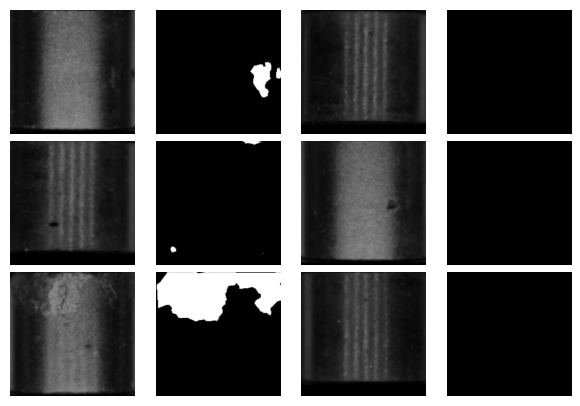

In [ ]:
# Muestra de imagenes y máscaras cargadas

import random

print("Train: ", len(X_train), len(y_train))
print("Test: ", len(X_test), len(y_test))
print("Val: ", len(X_val), len(y_val))

print("Train: ", type(X_train), 'input range: ', np.min(X_train), np.max(X_train))
print("Val: ", type(X_val), 'input range: ', np.min(X_val), np.max(X_val))
print("Test: ", type(X_test), 'input range: ', np.min(X_test), np.max(X_test))

print("Train: ", type(y_train), 'input range: ', np.min(y_train), np.max(y_train))
print("Val: ", type(y_val), 'input range: ', np.min(y_val), np.max(y_val))
print("Test: ", type(y_test), 'input range: ', np.min(y_test), np.max(y_test))

def show_grid(X, y, n=1):
    idxs = np.random.choice(X.shape[0], n, replace=False)
    plt.figure(figsize=(6, 4)) # Adjusted figure size to be narrower
    for i, idx in enumerate(idxs):
        plt.subplot(n//2, 4, 2*i+1) # Adjusted subplot grid for 2 rows and 4 columns
        plt.imshow(X[idx].astype("uint8"))
        plt.axis("off")
        plt.subplot(n//2, 4, 2*i+2) # Adjusted subplot grid
        plt.imshow(y[idx,...,0], cmap="gray")
        plt.axis("off")
    plt.tight_layout(pad=0.5) # Use tight_layout with a small pad
    plt.show()

show_grid(X_train, y_train, n=6)


#Definición del modelo y preprocesamiento de data

In [ ]:
model_type = "efficientnetb2"
#['resnet18', 'resnet34', 'resnet50', 'resnet101', 'resnet152', 'seresnet18', 'seresnet34', 'seresnet50', 'seresnet101', 'seresnet152',
#'seresnext50', 'seresnext101', 'senet154', 'resnext50', 'resnext101', 'vgg16', 'vgg19', 'densenet121', 'densenet169', 'densenet201',
#'inceptionresnetv2', 'inceptionv3', 'mobilenet', 'mobilenetv2', 'efficientnetb0', 'efficientnetb1', 'efficientnetb2', 'efficientnetb3',
#'efficientnetb4', 'efficientnetb5', 'efficientnetb6', 'efficientnetb7']
print(f'Cargando modelo: {model_type}')


preprocessed_input = get_preprocessing(model_type)

# Preprocesar las imágenes
X_train_preprocessed = preprocessed_input(np.copy(X_train))
X_val_preprocessed = preprocessed_input(np.copy(X_val))
X_test_preprocessed = preprocessed_input(np.copy(X_test))


# Asegurar que las máscaras tengan un solo canal
if y_train.ndim == 4 and y_train.shape[-1] == 3:
    y_train = np.mean(y_train, axis=-1, keepdims=True)
    y_val   = np.mean(y_val, axis=-1, keepdims=True)
    y_test  = np.mean(y_test, axis=-1, keepdims=True)

# Normalizar: de 0–255 a 0–1
if np.max(y_train) > 1:
    y_train = y_train / 255.0
    y_val   = y_val / 255.0
    y_test  = y_test / 255.0

# Binarizar por si quedaron valores intermedios
y_train = np.where(y_train > 0.5, 1, 0)
y_val   = np.where(y_val > 0.5, 1, 0)
y_test  = np.where(y_test > 0.5, 1, 0)

# Convertir a float32 (clave para evitar el TypeError)
y_train = y_train.astype('float32')
y_val   = y_val.astype('float32')
y_test  = y_test.astype('float32')

print("✅ Máscaras listas:", y_train.shape, y_train.dtype, np.unique(y_train))


print("Train: ", type(X_train_preprocessed), 'input range: ', np.min(X_train_preprocessed), np.max(X_train_preprocessed))
print("Val: ", type(X_val_preprocessed), 'input range: ', np.min(X_val_preprocessed), np.max(X_val_preprocessed))
print("Test: ", type(X_test_preprocessed), 'input range: ', np.min(X_test_preprocessed), np.max(X_test_preprocessed))

print("Unique y_train values:", np.unique(y_train))
print("Unique y_val values:", np.unique(y_val))


Cargando modelo: efficientnetb2
✅ Máscaras listas: (1050, 224, 224, 1) float32 [0. 1.]
Train:  <class 'numpy.ndarray'> input range:  -2.117904 1.9501214
Val:  <class 'numpy.ndarray'> input range:  -2.117904 1.3399688
Test:  <class 'numpy.ndarray'> input range:  -2.117904 1.7826903
Unique y_train values: [0. 1.]
Unique y_val values: [0. 1.]


#Entrenamiento

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
from datetime import datetime
import tensorflow as tf
import segmentation_models as sm
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, Callback
#from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.optimizers import Adam # Import Adamax optimizer
from tensorflow.keras.optimizers.schedules import ExponentialDecay # Import a scheduler
from keras.applications import EfficientNetB2
import string

print(f"🔧 Usando modelo: {model_type}")

# === Registro para serialización ===
@tf.keras.utils.register_keras_serializable(package="Custom")
def focal_tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3, gamma=1.5):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    TP = tf.reduce_sum(y_true_f * y_pred_f)
    FP = tf.reduce_sum((1 - y_true_f) * y_pred_f)
    FN = tf.reduce_sum(y_true_f * (1 - y_pred_f))

    tversky = (TP + 1e-6) / (TP + alpha * FP + beta * FN + 1e-6)
    loss = tf.pow((1 - tversky), gamma)

    return loss
@tf.keras.utils.register_keras_serializable(package="Custom")
def precision_m(y_true, y_pred):
    y_pred_pos = tf.round(tf.clip_by_value(y_pred, 0, 1))
    true_pos = tf.reduce_sum(y_true * y_pred_pos)
    predicted_pos = tf.reduce_sum(y_pred_pos)
    return true_pos / (predicted_pos + tf.keras.backend.epsilon())

@tf.keras.utils.register_keras_serializable(package="Custom")
def recall_m(y_true, y_pred):
    y_pred_pos = tf.round(tf.clip_by_value(y_pred, 0, 1))
    true_pos = tf.reduce_sum(y_true * y_pred_pos)
    possible_pos = tf.reduce_sum(y_true)
    return true_pos / (possible_pos + tf.keras.backend.epsilon())

@tf.keras.utils.register_keras_serializable(package="Custom")
def weighted_dice_loss(y_true, y_pred, smooth=1e-6 , weight=0.75):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    dice = (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)
    loss = 1 - dice
    weighted_loss = weight * loss + (1 - weight) * tf.reduce_mean(tf.square(y_pred_f - y_true_f))
    return weighted_loss

@tf.keras.utils.register_keras_serializable(package="Custom")
def weighted_combo_loss(y_true, y_pred, alpha=0.5, beta=0.5):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice_loss = weighted_dice_loss(y_true, y_pred)
    return alpha * bce + beta * dice_loss

@tf.keras.utils.register_keras_serializable(package="Custom")
def custom_bce_dice_loss(y_true, y_pred):
    return sm.losses.bce_dice_loss(y_true, y_pred)

@tf.keras.utils.register_keras_serializable(package="Custom")
def custom_iou_score(y_true, y_pred):
    return sm.metrics.iou_score(y_true, y_pred)

@tf.keras.utils.register_keras_serializable(package="Custom")
def custom_f1_score(y_true, y_pred):
    return sm.metrics.f1_score(y_true, y_pred)

# === 2. Rutas ===
checkpoint_path = f"{base_path}/model/checkpoints_{model_type}_{defect}/{model_type}_last.keras"
history_pkl_path = f"{base_path}/model/checkpoints_{model_type}_{defect}/{model_type}_history.pkl"
history_csv_path = f"{base_path}/model/checkpoints_{model_type}_{defect}/{model_type}_history.csv"
out_folder = f"{base_path}/output/model_{defect}"
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
os.makedirs(out_folder, exist_ok=True)

# === 3. Callback mejorado para guardar historial .pkl y actualizar .csv ===
class HistorySaver(Callback):
    def __init__(self, pkl_path, csv_path):
        super().__init__()
        self.pkl_path = pkl_path
        self.csv_path = csv_path

        # Cargar historial CSV existente si hay
        if os.path.exists(csv_path):
            self.df_history = pd.read_csv(csv_path, index_col="epoch")
        else:
            self.df_history = pd.DataFrame()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        new_row = pd.DataFrame([logs], index=[epoch])
        new_row.index.name = 'epoch'

        # Agregar nueva fila al historial existente
        self.df_history = pd.concat([self.df_history, new_row])
        self.df_history = self.df_history[~self.df_history.index.duplicated(keep='last')]
        self.df_history.sort_index(inplace=True)

        # Guardar como CSV
        self.df_history.to_csv(self.csv_path)
        print(f"📝 CSV actualizado hasta época {epoch + 1}")

        # También guardar como .pkl para reanudar
        with open(self.pkl_path, 'wb') as f:
            pickle.dump(self.df_history.to_dict(orient='list'), f)

# === Callback para imprimir Learning Rate ===
class LearningRateLogger(Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        # If the learning rate is a callable (like a scheduler), get its current value
        if hasattr(lr, '__call__'):
             lr = lr(self.model.optimizer.iterations)
        print(f"\nEpoch {epoch+1}: Learning Rate = {tf.keras.backend.get_value(lr):.6f}")


# === 4. Función para verificar historial válido ===
def valid_history(hist):
    return (
        isinstance(hist, dict) and
        'loss' in hist and
        isinstance(hist['loss'], list) and
        len(hist['loss']) > 0
    )


# === 5. Cargar o crear modelo ===
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
print(f"Attempting to load model from: {checkpoint_path}")

if os.path.exists(checkpoint_path):
    print(f"🔁 Cargando modelo completo desde: {checkpoint_path}")
    model = tf.keras.models.load_model(
        checkpoint_path,
        custom_objects={
            'weighted_combo_loss': weighted_combo_loss,
            'custom_iou_score': custom_iou_score,
            'custom_f1_score': custom_f1_score
        },
        safe_mode=False
    )

else:
    base_model = EfficientNetB2(
    include_top=False,
    weights="imagenet",  # ✅ Esto baja desde los servidores de Keras (funciona)
    input_shape=(224,224,3)
)

# 🧩 Ahora usamos ese encoder dentro de segmentation_models
    model = sm.Unet(
    backbone_name='efficientnetb2',
    encoder_weights=None,   # ❌ No descargues desde segmentation_models
    classes=1,
    activation='sigmoid'
)

# Copiamos los pesos del encoder base al modelo Unet
for i, layer in enumerate(base_model.layers):
    try:
        model.get_layer(index=i).set_weights(layer.get_weights())
    except:
        pass  # algunas capas no coinciden en nombre o forma

print("✅ Pesos de ImageNet cargados desde Keras correctamente.")



#Usamos un LR inicial moderado (1e-3) y dejamos que ReduceLROnPlateau lo ajuste.
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss= weighted_combo_loss,
    metrics=[custom_iou_score, custom_f1_score, precision_m, recall_m]
)

# === 6. Cargar historial si existe ===
if os.path.exists(history_pkl_path):
    with open(history_pkl_path, 'rb') as f:
        previous_history = pickle.load(f)
    if valid_history(previous_history):
        print(f"📈 Historial cargado con {len(previous_history['loss'])} épocas.")
    else:
        previous_history = None
        os.remove(history_pkl_path)
        print("⚠️ Historial inválido. Se iniciará desde cero.")
else:
    previous_history = None
    print("📉 No se encontró historial previo.")

initial_epoch = len(previous_history['loss']) if previous_history else 0

callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True),
    ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=False,
        save_weights_only=False  # ✅ Guarda modelo completo (.keras)
    ),
    HistorySaver(history_pkl_path, history_csv_path),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,       # reduce a la mitad cuando no mejora
        patience=5,        # espera 5 epochs sin mejora
        min_lr=1e-6,       # no baja más de este valor
        verbose=1
    )
]

# === 7. Entrenamiento ===
batch_size = 16
epochs = 100


import time

start_time = time.time()
history = model.fit(
    x=X_train_preprocessed,
    y=y_train,
    batch_size=batch_size,
    epochs=epochs,
    initial_epoch=initial_epoch,
    validation_data=(X_val_preprocessed, y_val),
    callbacks=callbacks,
    verbose=1
)
training_time = time.time() - start_time
print(f"⏱ Tiempo total de entrenamiento: {training_time:.2f} s")




🔧 Usando modelo: efficientnetb2
Attempting to load model from: /content/drive/MyDrive/IV/model/checkpoints_efficientnetb2_cachaduras/efficientnetb2_last.keras
✅ Pesos de ImageNet cargados desde Keras correctamente.
📉 No se encontró historial previo.
Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - custom_f1_score: 0.0526 - custom_iou_score: 0.0272 - loss: 0.6507 - precision_m: 0.1051 - recall_m: 0.3818   📝 CSV actualizado hasta época 1
66/66 ━━━━━━━━━━━━━━━━━━━━ 285s 2s/step - custom_f1_score: 0.0527 - custom_iou_score: 0.0273 - loss: 0.6489 - precision_m: 0.1065 - recall_m: 0.3796 - val_custom_f1_score: 0.0354 - val_custom_iou_score: 0.0181 - val_loss: 0.4263 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - custom_f1_score: 0.1561 - custom_iou_score: 0.0883 - loss: 0.3690 - precision_m: 0.3546 - recall_m: 0.4437📝 CSV actualizado hasta época 2
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 260ms/step - custom_f1_

In [ ]:
# === 8. Guardar modelo final completo ===
now = datetime.now().strftime("%Y%m%d")
letters = ''.join(random.choices(string.ascii_uppercase, k=2))
numbers = ''.join(random.choices(string.digits, k=1))
code = f"{letters}{numbers}"
file_name = f"{now}-{code}-{model_type}-{defect}.keras" # Corrected string formatting

final_model_path = f'{out_folder}/{file_name}'
os.makedirs(os.path.dirname(final_model_path), exist_ok=True) # Explicitly create directory for the final model
model.save(final_model_path)
print(f"✅ Modelo final guardado: {final_model_path}")

# === 9. Evaluación ===
print("\n📊 Validación:")
model.evaluate(X_val_preprocessed, y_val)

print("\n📊 Test:")
model.evaluate(X_test_preprocessed, y_test)

# === 10. Predicción ===
pred = model.predict(X_test_preprocessed)

✅ Modelo final guardado: /content/drive/MyDrive/IV/output/model_cachaduras/20251031-ZA0-efficientnetb2-cachaduras.keras

📊 Validación:
8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 100ms/step - custom_f1_score: 0.6574 - custom_iou_score: 0.4955 - loss: 0.1680 - precision_m: 0.7685 - recall_m: 0.5926

📊 Test:
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - custom_f1_score: 0.7015 - custom_iou_score: 0.5501 - loss: 0.1468 - precision_m: 0.7869 - recall_m: 0.6415 
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step 


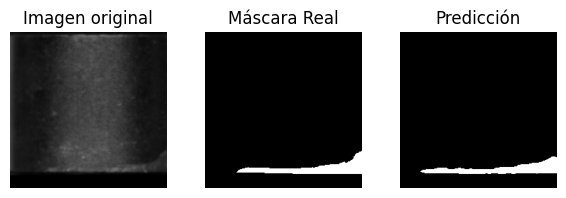

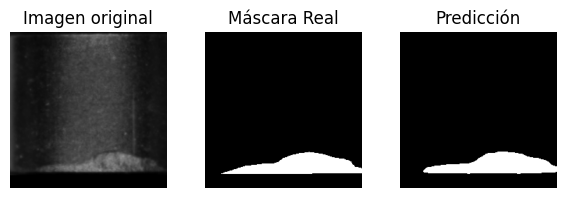

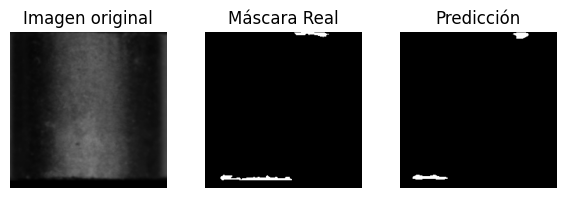

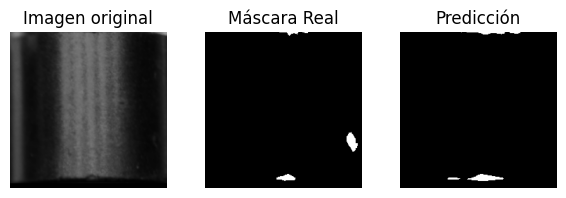

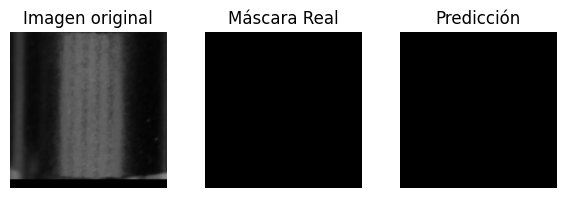

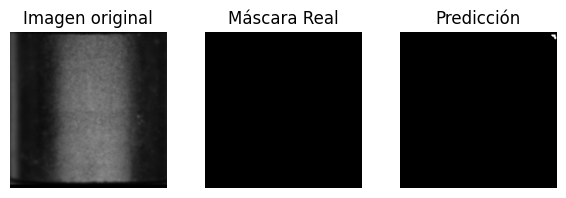

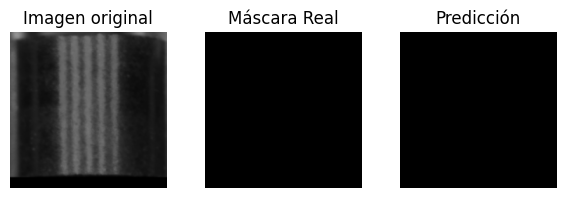

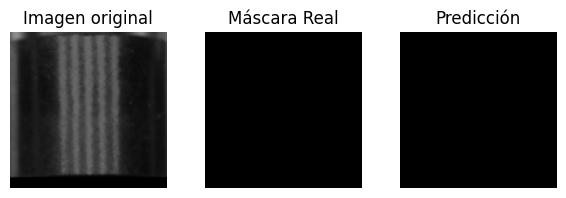

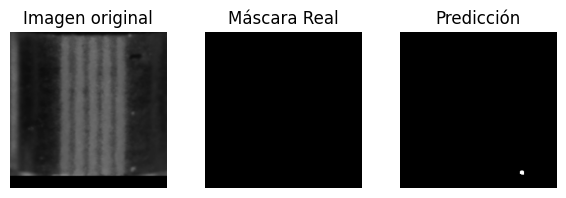

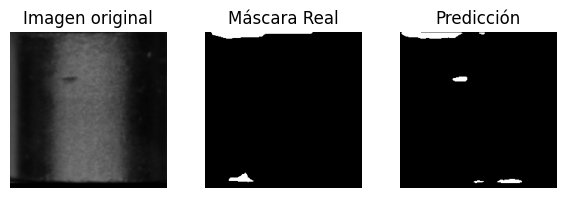

In [ ]:
import matplotlib.pyplot as plt
import os
import numpy as np

# === 1. Generar predicciones (si no lo hiciste ya) ===
y_pred = model.predict(X_test_preprocessed)

# Define the base directory for output and predictions
#output_dir = f"{base_path}/output"
#predictions_dir = os.path.join(output_dir, f"predictions_{defect}_{model_type}")
#results_dir = os.path.join(predictions_dir, f"visualizations_{defect}_{model_type}") # Keep visualization directory as before

# Create the necessary directories if they don't exist
#os.makedirs(predictions_dir, exist_ok=True)
#os.makedirs(results_dir, exist_ok=True)

# === 2. Guardar predicciones como .npy ===
#np.save(os.path.join(predictions_dir, "y_pred_test.npy"), y_pred)
#print("✅ Predicciones guardadas.")

# === 3. Visualizar y guardar comparaciones ===
# Escala las máscaras para visualización (umbral opcional)
threshold = 0.5
y_pred_bin = (y_pred > threshold).astype(np.uint8)

# Iterar over a limited number of samples to avoid too many figures
num_samples_to_show = 10 # You can adjust this number
for i in range(min(len(X_test), num_samples_to_show)):
    fig, axes = plt.subplots(1, 3, figsize=(6, 2)) # Changed figsize to make figures smaller
    original_image_display = np.clip(X_test[i], 0, 255).astype(np.uint8)


    # Imagen original
    axes[0].imshow(original_image_display)
    axes[0].set_title("Imagen original")
    axes[0].axis("off")

    # Ground truth
    axes[1].imshow(y_test[i].squeeze(), cmap='gray')
    axes[1].set_title("Máscara Real")
    axes[1].axis("off")

    # Predicción
    axes[2].imshow(y_pred_bin[i].squeeze(), cmap='gray')
    axes[2].set_title("Predicción")
    axes[2].axis("off")

    plt.tight_layout()
    #save_path = os.path.join(results_dir, f"test_{i:03d}.png")
    #plt.savefig(save_path)
    #plt.close(fig) # Close the figure to free memory

#print(f"🖼️ Visualizaciones guardadas en: {results_dir}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os # Import os for path joining

def plot_history(history, x_lim, y_lim, save_path=None): # Added save_path parameter
    #val_iou_score = history.history['val_iou_score']
    #iou_score = history.history['iou_score']
    val_custom_f1_score = history.history['val_custom_f1_score']
    custom_f1_score = history.history['custom_f1_score']
    val_loss = history.history['val_loss']
    loss = history.history['loss']
    epochs = range(1, len(loss) + 1)

    # Plotting
    plt.figure(figsize=(12, 6))

    #plt.plot(epochs, val_iou_score, 'b', label='Validation IoU Score')
    #plt.plot(epochs, iou_score, 'g', label='IoU Score')
    plt.plot(epochs, custom_f1_score, 'r', label='F1 Score')
    plt.plot(epochs, val_custom_f1_score, 'c', label='Validation F1 Score')
    plt.plot(epochs, val_loss, 'm', label='Validation Loss')
    plt.plot(epochs, loss, 'y', label='Training Loss')

    plt.title('Training Metrics', fontsize=16)
    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Score/Loss', fontsize=14)
    plt.legend(fontsize=12)

    plt.grid(True)
    plt.xlim(1, x_lim)
    plt.ylim(0, y_lim)

    if save_path: # Save the figure if save_path is provided
        plt.savefig(save_path)
        print(f"📊 Plot saved to: {save_path}")

    plt.show()

📊 Plot saved to: /content/drive/MyDrive/IV/output/model_cachaduras/training_metrics_20251031-ZA0-efficientnetb2-cachaduras.png


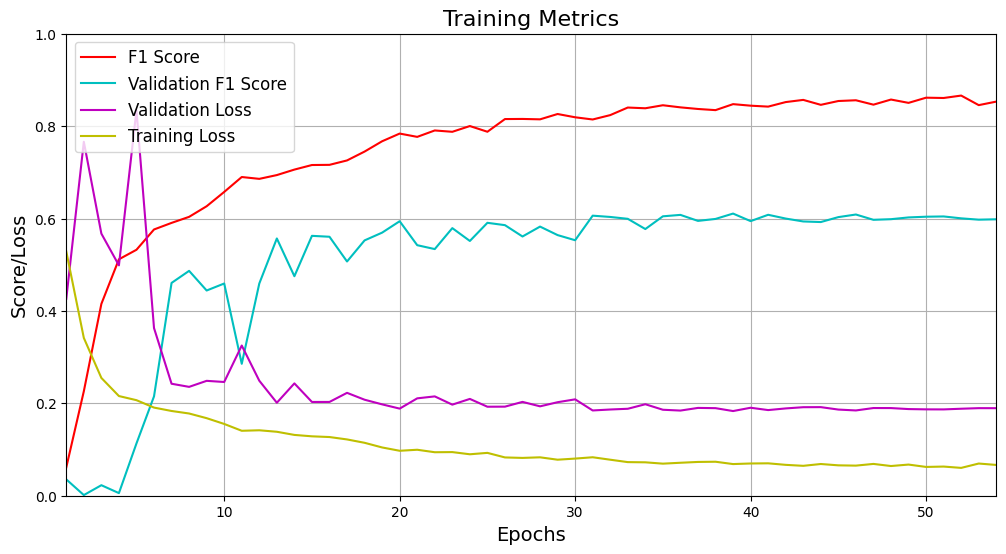

In [ ]:
# Visualize the training history
# Define the output folder (assuming out_folder is defined in the training cell)
plot_output_folder = f'{out_folder}'

os.makedirs(plot_output_folder, exist_ok=True) # Ensure the directory exists

# Define the save path for the plot (using a similar naming convention as the model)
# You might want to get the exact model filename from the previous cell if you want to match it
# For now, let's use a generic name based on model type and defect
plot_save_path = os.path.join(plot_output_folder, f"training_metrics_{now}-{code}-{model_type}-{defect}.png")


plot_history(history, x_lim=len(history.history['loss']), y_lim=1.0, save_path=plot_save_path) # Added save_path

In [ ]:
from google.colab import drive
import os
from datetime import datetime # Import datetime

# 2️⃣ Carpeta donde querés guardar el archivo
folder_path = f'{base_path}/output'
  # Cambialo por tu carpeta
os.makedirs(folder_path, exist_ok=True)  # Crea la carpeta si no existe

# 3️⃣ Nombre del archivo
txt_file = os.path.join(folder_path, "logs_experimentos.txt")


# 4️⃣ Evaluación
# Unpack all returned values
val_loss, val_iou, val_f1, val_precision, val_recall = model.evaluate(X_val_preprocessed, y_val, verbose=0)
test_loss, test_iou, test_f1, test_precision, test_recall = model.evaluate(X_test_preprocessed, y_test, verbose=0)


# 5️⃣ Datos a guardar
row = [
    file_name,                     # Nombre del archivo del modelo
    defect,                        #defecto
    datetime.now().strftime("%Y-%m-%d"),  # Fecha actual
    len(history.history['loss']),  # Número de épocas entrenadas
    model_type,                    # Tipo de modelo
    round(val_f1, 4),              # F1 Score validación
    round(val_loss, 4),            # Dice loss validación
    round(val_iou, 4),             # IoU score validación
    round(test_iou, 4),            # IoU score test
    round(test_f1, 4),             # F1 Score test
    round(training_time, 2)        # Tiempo entrenamiento en segundos
]



# 6️⃣ Guardar en txt en Drive
with open(txt_file, "a") as f:
    f.write("\t".join(map(str, row)) + "\n ")

print(f"✅ Registro guardado en {txt_file}")

✅ Registro guardado en /content/drive/MyDrive/IV/output/logs_experimentos.txt


In [ ]:
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

Test Precision: 0.7766
Test Recall: 0.6274
